# Homework 6: Linear Regression Modleing and Diagnostics
Build a predictive model for life expectancy using scikit-learn and perform a diagnostic audit to ensure the model’s coefficients are stable and mathematically sound.

## Task 1: Baseline Modeling
Load the WHO Life Expectancy Dataset, remove non-numeric columns (Country, Year), Convert Status column to  numeric, handle missing values.
- Use StandardScaler from sklearn.preprocessing to scale all independent variables. ("Life expectancy" is dependent variable) 
- Train a LinearRegression model using the scaled features.
- Report the R-Squared Score.
- Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.

## Task 2: Iterative Diagnostic (VIF < 5)
Before analyzing the data, you must understand the Variance Inflation Factor (VIF) diagnostic. VIF measures multicollinearity, the degree to which your predictors are redundant.
High multicollinearity inflates the variance of coefficients, making them unreliable and difficult to interpret.
VIF is calculated by regressing one predictor against all others, then you obtain R_Squared and then compute VIF = 1/(1-R_Squared)
You sohuld use a cutoff of 5. Any variable with a VIF > 5 is considered too redundant and will be removed to improve the model's structural integrity. To do that follow the instruction below:

### Write a loop to iteratively remove the most redundant feature:
    1. Calculate VIF for every feature in the scaled dataset.
    2. Find the variable with the highest VIF.
    3. If VIF > 5, remove that feature from the data.
    4. Repeats the process until all remaining features have a VIF < 5
    - Note that in each iteration you remove only the highest VIF if it is greatet than 5!
    
## Task 3: Comparison of Model Results
    - Train a new LinearRegression model using only the independent features that survived the VIF diagnostic test.
    - Report the R-Squared Score.
    - Coefficient Analysis: Rank the features by their absolute coefficient values. Because the data is scaled, the largest coefficient now represents the most important predictor.
    - Are the top 5 predicotrs remain the same as those of the Baseline Model?
#### The top 5 predictors did not remain the same because it showed HIV/AIDS and Schooling are the most reliable predictors of life expectancy.

## Task 4: Residual Analysis and Normality
A good regression model should have errors (residuals) that are normally distributed and centered around zero.

    - Generate a histogram of the residuals for your baseline and clean model side by side.
    - Does the error distributions look like a bell curve?
#### Yes, they do, they are roughly the same shape.

## Task 5: The Interaction Investigation
In the real world application, the effect of one variable often depends on another. This is called an interaction.

    - Select two variables of your choice from the dataset (only variables with VIF >5) that you believe might have a combined effect (e.g., Alcohol and GDP, or BMI and HIV/AIDS,). Write one sentence explaining why you think they interact.
#### I think GDP and Alcohol interact because a country with more money can provide better healthcare to fix the health problems caused by drinking.
    - Create a new column in your dataframe by multiplying these two variables together.
    - Train a new model by adding this new interaction term to your dataset and fit it again using LinearRegression.
    - Report the R-Squared Score.
    - Is the interaction coeficient positive or negative? Has adding it improved the Model performance?
#### The R-Squared score is 0.8279 and the interaction coefficient is negative (-0.000003). Adding it did not meaningfully improve the model performance since the R-Squared score only increased from 0.8278 to 0.8279.

### Task 1

In [4]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [7]:
df = pd.read_csv('Life_Expectancy_Data.csv') # Ensure file name matches
df = df.drop(['Country', 'Year'], axis=1)
df['Status'] = df['Status'].map({'Developed': 1, 'Developing': 0})
df = df.dropna()


X = df.drop('Life expectancy ', axis=1)
y = df['Life expectancy ']

scaler = StandardScaler()
X_scaled_np = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_np, columns=X.columns)


baseline_model = LinearRegression().fit(X_scaled, y)
print(f"Baseline R-Squared: {baseline_model.score(X_scaled, y):.4f}")


coef_df = pd.DataFrame({'Feature': X.columns, 'Coef': np.abs(baseline_model.coef_)})
print(coef_df.sort_values(by='Coef', ascending=False))

Baseline R-Squared: 0.8356
                            Feature       Coef
8                under-five deaths   11.456132
2                     infant deaths  11.295750
12                         HIV/AIDS   2.635125
18                        Schooling   2.421478
1                   Adult Mortality   2.083498
17  Income composition of resources   1.796758
7                              BMI    0.666615
4            percentage expenditure   0.646033
3                           Alcohol   0.368136
0                            Status   0.342668
11                      Diphtheria    0.321418
16               thinness 5-9 years   0.223236
9                             Polio   0.178097
10                Total expenditure   0.174374
5                       Hepatitis B   0.167011
13                              GDP   0.100245
6                          Measles    0.079305
15             thinness  1-19 years   0.056944
14                       Population   0.045255


### Task 2

In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X_scaled.copy()

while True:
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_vif.columns
    vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(len(X_vif.columns))]
    
    max_vif = vif_data["VIF"].max()
    max_feature = vif_data.loc[vif_data["VIF"] == max_vif, "feature"].values[0]
    
    
    if max_vif > 5:
        print(f"Removing '{max_feature}' with VIF: {max_vif:.2f}")
        X_vif = X_vif.drop(columns=[max_feature])
    else:
        
        break

print("\nFinal features remaining for Task 3:")
print(X_vif.columns.tolist())

Removing 'infant deaths' with VIF: 212.19
Removing 'GDP' with VIF: 13.57
Removing ' thinness  1-19 years' with VIF: 7.60

Final features remaining for Task 3:
['Status', 'Adult Mortality', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles ', ' BMI ', 'under-five deaths ', 'Polio', 'Total expenditure', 'Diphtheria ', ' HIV/AIDS', 'Population', ' thinness 5-9 years', 'Income composition of resources', 'Schooling']


### Task 3

In [15]:
final_model = LinearRegression()
final_model.fit(X_vif, y)


final_r2 = final_model.score(X_vif, y)
print(f"Final Model R-Squared: {final_r2:.4f}")


final_coeffs = pd.DataFrame({
    'Feature': X_vif.columns,
    'Coefficient': final_model.coef_
})
final_coeffs['Abs_Coef'] = final_coeffs['Coefficient'].abs()
final_ranked = final_coeffs.sort_values(by='Abs_Coef', ascending=False)

print("\nFinal Model Top 5 Predictors:")
print(final_ranked.head(5))

Final Model R-Squared: 0.8278

Final Model Top 5 Predictors:
                            Feature  Coefficient  Abs_Coef
11                         HIV/AIDS    -2.647613  2.647613
15                        Schooling     2.492107  2.492107
1                   Adult Mortality    -2.207173  2.207173
14  Income composition of resources     1.903432  1.903432
3            percentage expenditure     0.722333  0.722333


### Task 4

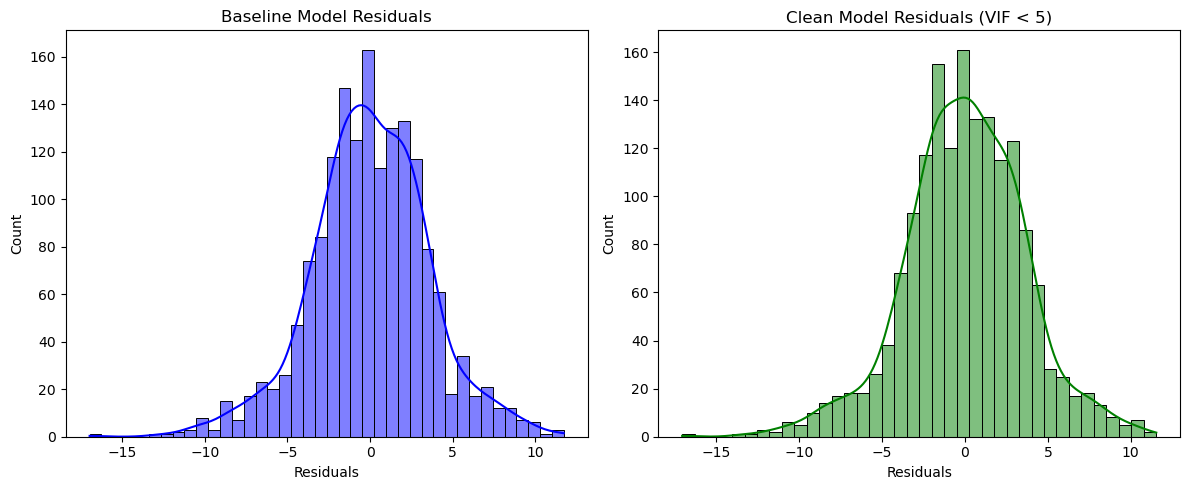

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

baseline_preds = baseline_model.predict(X_scaled)
baseline_residuals = y - baseline_preds

clean_preds = final_model.predict(X_vif)
clean_residuals = y - clean_preds

#Plotting histograms
plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
sns.histplot(baseline_residuals, kde=True, color='blue')
plt.title('Baseline Model Residuals')
plt.xlabel('Residuals')


plt.subplot(1, 2, 2)
sns.histplot(clean_residuals, kde=True, color='green')
plt.title('Clean Model Residuals (VIF < 5)')
plt.xlabel('Residuals')

plt.tight_layout()
plt.show()

### Task 5

In [17]:
df['GDP_Alcohol_Interaction'] = df['GDP'] * df['Alcohol']

X_interaction = X_vif.copy()
X_interaction['Interaction'] = df['GDP_Alcohol_Interaction']

interaction_model = LinearRegression().fit(X_interaction, y)

print(f"Interaction Model R-Squared: {interaction_model.score(X_interaction, y):.4f}")

coef_dict = dict(zip(X_interaction.columns, interaction_model.coef_))
print(f"Interaction Coefficient: {coef_dict['Interaction']:.6f}")

Interaction Model R-Squared: 0.8279
Interaction Coefficient: -0.000003
